# LSTM model with full input (no PCA)

**Directly predict *near-term* volatility from the full set of features.**

Author: Pete King

Here again we train a LSTM model to predict near-term volatility for a single ETF, but this time we use all features available in the dataset.

The purpose of this notebook is to explore how well the model adapts to a large amount of additional features, compared to our original test using very limited input (returns and historical volatility), and later to an expanded but still limited set of extracted features the we developed using PCA.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 10  # No. observations in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_vol_target']
train_df[data_cols + label_col].head(SEQUENCE_LENGTH + 1)

,BIL_vol-h,BND_vol-h,GLD_vol-h,HYG_vol-h,IEF_vol-h,IWM_vol-h,LQD_vol-h,QQQ_vol-h,SPY_vol-h,TIP_vol-h,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2015-10-15,0.000000,0.002022,0.011018,0.001742,0.003279,0.013053,0.002561,0.008202,0.007701,0.002297,...,0.000709,0.023973,0.008357,0.015144,0.015087,0.008546,0.007600,0.011329,0.042,0.008268
2015-10-16,0.000000,0.002028,0.009054,0.002690,0.003291,0.013036,0.002558,0.008165,0.007959,0.002276,...,0.000740,0.025340,0.007221,0.008305,0.015647,0.008503,0.007862,0.011671,0.000,0.009382
2015-10-19,0.000000,0.001878,0.009074,0.002824,0.002939,0.013047,0.001812,0.008487,0.007951,0.002262,...,0.000749,0.016360,0.007512,0.010626,0.014675,0.008102,0.007842,0.010355,0.005,0.009444
2015-10-20,0.000098,0.001989,0.009245,0.002653,0.003289,0.011520,0.001968,0.008304,0.007453,0.002309,...,0.000778,0.016158,0.007714,0.009271,0.014504,0.007859,0.007247,0.010169,0.043,0.009466
2015-10-21,0.000138,0.001399,0.006450,0.002676,0.002689,0.012664,0.002383,0.008714,0.007660,0.001759,...,0.000482,0.016521,0.006746,0.007679,0.019282,0.005936,0.007408,0.009758,-0.041,0.010365
2015-10-22,0.000138,0.001334,0.006119,0.002465,0.002259,0.007997,0.002559,0.010206,0.008268,0.002173,...,0.000434,0.016427,0.006081,0.008524,0.015694,0.003880,0.008111,0.004352,-0.005,0.007168
2015-10-23,0.000138,0.001749,0.005289,0.002079,0.003372,0.009101,0.003035,0.015906,0.009382,0.001920,...,0.000529,0.016103,0.005996,0.010138,0.024396,0.005458,0.009258,0.006505,0.058,0.005598
2015-10-26,0.000169,0.001817,0.004954,0.001759,0.003561,0.009564,0.003139,0.015702,0.009444,0.001765,...,0.000505,0.011200,0.004764,0.007755,0.052128,0.005485,0.009296,0.006540,-0.025,0.007602
2015-10-27,0.000138,0.001677,0.004191,0.002249,0.003402,0.010739,0.003026,0.015558,0.009466,0.001962,...,0.000459,0.013357,0.004416,0.007751,0.052162,0.006551,0.009345,0.006342,-0.030,0.007663


In [3]:
val_df[data_cols + label_col]

,BIL_vol-h,BND_vol-h,GLD_vol-h,HYG_vol-h,IEF_vol-h,IWM_vol-h,LQD_vol-h,QQQ_vol-h,SPY_vol-h,TIP_vol-h,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.000254,0.004925,0.006532,0.009604,0.005977,0.013817,0.007952,0.014183,0.010149,0.003497,...,0.000963,0.022127,0.007543,0.006287,0.076669,0.007242,0.009848,0.010195,-0.086,0.012281
2023-01-04,0.000259,0.004318,0.006791,0.009841,0.005767,0.014577,0.006326,0.012850,0.010569,0.002845,...,0.000869,0.032962,0.006712,0.006061,0.077316,0.007436,0.010246,0.017094,-0.084,0.013061
2023-01-05,0.000259,0.004302,0.008570,0.007809,0.005703,0.013663,0.006178,0.013401,0.010334,0.002803,...,0.001059,0.033193,0.007824,0.011092,0.077269,0.007927,0.010157,0.017635,0.011,0.012119
2023-01-06,0.000176,0.006304,0.011658,0.008238,0.007773,0.012654,0.008994,0.014555,0.012081,0.004593,...,0.001979,0.033046,0.010177,0.015203,0.075911,0.008764,0.012052,0.017319,-0.151,0.006860
2023-01-09,0.000196,0.006144,0.011513,0.008383,0.007631,0.012615,0.008717,0.014836,0.012026,0.004513,...,0.001951,0.031764,0.010378,0.019542,0.079023,0.008104,0.012003,0.019215,-0.052,0.006905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.000244,0.003170,0.007777,0.002821,0.003586,0.016564,0.003549,0.009930,0.006228,0.003421,...,0.001454,0.023840,0.007865,0.008386,0.032072,0.005039,0.006967,0.008671,0.011,0.010568
2024-08-27,0.000244,0.002881,0.007698,0.002807,0.003112,0.016092,0.003373,0.009975,0.006215,0.002928,...,0.001329,0.026203,0.007686,0.008428,0.033437,0.002324,0.006947,0.008752,0.015,0.010590
2024-08-28,0.000229,0.002733,0.008298,0.002625,0.002983,0.015320,0.003350,0.011010,0.006562,0.002758,...,0.001238,0.023572,0.008122,0.011942,0.033711,0.002260,0.007202,0.009387,0.008,0.010323


## II. PyTorch Multivariate LSTM Model

### Create Datasets and DataLoaders

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([10, 58])
Shape of first training label: torch.Size([1])


In [6]:
print(X_0)

tensor([[ 0.0000e+00,  2.0222e-03,  1.1018e-02,  1.7422e-03,  3.2794e-03,
          1.3053e-02,  2.5609e-03,  8.2020e-03,  7.7006e-03,  2.2972e-03,
          5.7827e-03,  5.6822e-03,  1.1930e-02,  1.1622e-02,  8.5099e-03,
          6.1794e-03,  7.2774e-03,  4.2555e-03,  8.0131e-03,  1.1644e-02,
          8.0563e-03,  0.0000e+00,  1.0000e-02,  0.0000e+00,  1.0000e-02,
          4.0000e-02,  5.0000e-02,  5.0000e-02,  3.0000e-02,  1.8211e-03,
          1.8448e-03,  4.0614e-02,  1.5895e-02,  9.8948e-04,  1.8577e-03,
          0.0000e+00,  3.2923e-04, -2.7298e-03,  0.0000e+00, -3.6364e-02,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  7.0039e-02, -7.4906e-03,
          3.1717e-03,  1.6050e+01,  1.8070e+01,  7.4600e+01,  7.0923e-04,
          2.3973e-02,  8.3570e-03,  1.5144e-02,  1.5087e-02,  8.5460e-03,
          7.5997e-03,  1.1329e-02,  4.2000e-02],
        [ 0.0000e+00,  2.0280e-03,  9.0537e-03,  2.6897e-03,  3.2910e-03,
          1.3036e-02,  2.5582e-03,  8.1653e-03,  7.9589e-03,  2

In [7]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 10, 58])
Shape of first batch of labels: torch.Size([21, 1])


In [8]:
print(y_0)

tensor([0.0059])


### Instantiate and train LSTM model

Here we increase the number of neurons in the hidden layer to allow the model to capture more complex relationships in the input data.  This could lead to overfitting if we set it too high.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(58, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.001163179986178875
Validation loss: 0.002405424602329731
Epoch 20
Training loss:   0.0015193410217761993
Validation loss: 0.00241856905631721
Epoch 30
Training loss:   0.0008214656263589859
Validation loss: 0.002697480609640479
Epoch 40
Training loss:   0.0012226123362779617
Validation loss: 0.0025111795403063297
Epoch 50
Training loss:   0.0003371788188815117
Validation loss: 0.002945288084447384
Epoch 60
Training loss:   0.001875709742307663
Validation loss: 0.0030693551525473595
Epoch 70
Training loss:   0.0012315912172198296
Validation loss: 0.0025683327112346888
Epoch 80
Training loss:   0.00153354462236166
Validation loss: 0.0029163770377635956
Epoch 90
Training loss:   0.0008650654926896095
Validation loss: 0.0025165537372231483
Epoch 100
Training loss:   0.0005652615800499916
Validation loss: 0.0025353501550853252


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


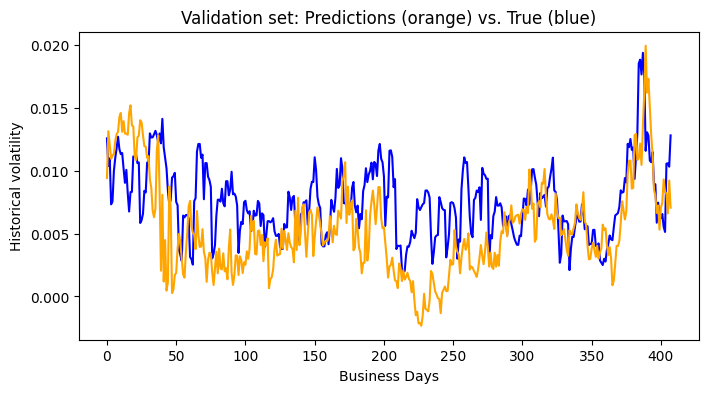

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')

The full set of features appears to have introduced too much noise -- the model behaves much less consistently than in the case with limited input.

In [15]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -1.0312561988830566
MAE: 0.0032620455604046583
RMSE: 0.004093279130756855
MSE: 1.675493513175752e-05
